# NBA play-by-play data + win probabilities

## Parts of this notebook:
1. Load play-by-play data from NBA API (or pre-read files)
2. Find team indices, winner of each game, adjustments for team strengths, clean data, etc.
2. Compute win probability and plot

---

# MODIFICATION NOTES (FONTAINE)
- General:
    - Indentation errors
    - Unclear names of variables
- Cell 1: numerous unused packages

#### Variable dictionary
In df1:
- home: home team id
- vis: visiting team id
- sl_ot: == sl 	
- hw: home win
- sl: second left
- hwp: home win probability: vecteur divisé en pas de temps et rempli dans le précédent notebook en deux étapes : i) repérer les moments t où l'équipe à domicile possède le ballon mais est en position de faiblesse en terme de force relative à ces moments t (i.e., comparaision de la variable ajustée à la différence de score absolue à t), ii) repère les moments où l'équipe à domicile est en position de force (élément = 1) ou non (élément = 0) sans considérer la possession du ballon. 
- sdiff: score difference (+ win, - fail wrt home team)
- sdiff_adj: invoquer df_svr
    - s0 = PS-PA (différence de score moyen de la home team sur la saison): force intrinsèque de l'équipe sur la saison. On calcule les scores de l'équipe à domicile et de l'équipe extérieure
    - s1 = s0_home - s0_ext (différence de force: force relative de la team home par rapport à la team ext)
    - sdiff_adj: évolution de la force relative au cours du match en seconde
- mwwp: min home win probability
- fgsur: starting fail probability
- wgsur: starting win probability
- hp: home ball possession

In df_svr:
- PS: score moyen de l'équipe à l'année y (points marqués par match)
- PA: score moyen de l'équipe à l'année y (points encaissés par match)

In [ ]:
import time
import math
import datetime
import numpy as np
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
pd.set_option('display.max_rows',100)
fs,fsz=30,10 #font/figure size
folder = ... #r'bball_am-main'

'''
### NBA API command (not used for replication)
from nba_api.stats.endpoints import leaguegamefinder
from nba_api.stats.static import teams
from nba_api.stats.endpoints import playbyplay
'''

'\n### NBA API command (not used for replication)\nfrom nba_api.stats.endpoints import leaguegamefinder\nfrom nba_api.stats.static import teams\nfrom nba_api.stats.endpoints import playbyplay\n'

# 1. Load play-by-play data from NBA API (or pre-read files)

# Create win probability space
Here we compute win probabilities using 4 factors (as in Antony et al., 2021):
- The score difference before each possession.
- The points scored / game - points scored against / game _difference_ between the teams for that season (difference in team strength)
- (The two above are wrapped into one metric below: the _expected_ score difference using the actual score difference and the expected difference in later scores given team strengths)
- The amount of time left in the game
- The team in possession of the ball

In [72]:
# read the dataset
df1 = pd.read_csv(f'{folder}/df1.csv')

In [165]:
def g_divider (sl , n) : 
    sl = sl/2880 
    nq = np.arange(0, 1 , 1/n)
    return np.argmin(np.abs(nq - sl))

df1['quarter'] = df1['sl'].apply(lambda x: g_divider(x,16)+1)

In [164]:
def adj_sdiff(s):
    if s > 30:
        return 30
    elif s < -30:
        return -30
    else:
        return s

df1['sdiff_adj_30'] = df1['sdiff_adj'].apply(adj_sdiff)

In [167]:
def get_HomeWinProba_perQuarter(df1):
    df2 = df1[['g_id','g_d','sl_ot','sdiff','sdiff_adj','sdiff_adj_30','hp','hw','quarter']].copy(deep=True)
    df2['sdiff_adj']
    wp=np.zeros((len(df2)))
    ids= df2['g_id'].unique()
    xsd,nsd,=30,-30
    scoreDiffSteps=1+xsd-nsd
    scoreDiffB=np.linspace(nsd,xsd,scoreDiffSteps)
    quarters = df2["quarter"].unique()
    fact4i = np.zeros((len(quarters),len(scoreDiffB)))
    for i in tqdm(quarters):
        for j in scoreDiffB:
            subdf = df2[(df2['quarter']==i ) & (df2['sdiff_adj_30']==j)]
            if len(subdf)>0 :
                q = np.array(subdf.index)
                a = subdf['hw'].mean() #calculate wp 
                wp[q]=a
                fact4i[i-1,int(j-nsd)]=a
            else : 
                pass 

    q=np.where(df2['sdiff_adj']>scoreDiffB[-1])
    wp[q]=0.998 #ceiling
    q=np.where(df2['sdiff_adj']<scoreDiffB[0])[0]
    wp[q]=0.002 #floor
    
    for ii in tqdm(df2.g_id.unique()): #loop through all games
        game = df2[df2['g_id']==ii]
        q = np.array(game.index)
        if game['sdiff'].values[-1]>0: #if home team won
            wp[q[-1]]=1
        elif game['sdiff'].values[-1]<0: #if vis team won
            wp[q[-1]]=0
        
        q1 = np.where(game['sl_ot'].diff()>0)[0] 
        if len(q1)>0:
            wp[q1]=wp[q[0]] #set state to original home win prob

    secB = np.linspace(0,2880,len(quarters)+1)

    return wp, secB, fact4i, scoreDiffB

wp, secB, fact4i, scoreDiffB = get_HomeWinProba_perQuarter(df1)

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/22539 [00:00<?, ?it/s]

<AxesSubplot:>

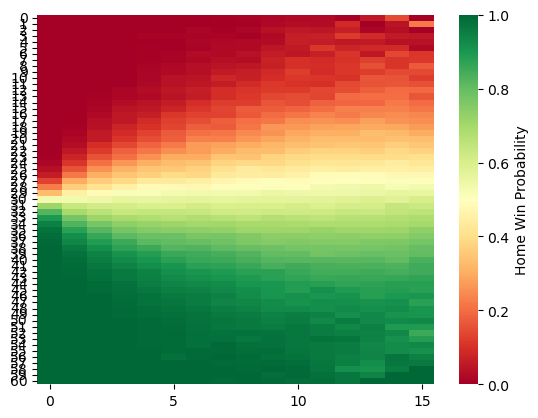

In [171]:
sns.heatmap(fact4i.T, xticklabels=5, yticklabels=1, cmap='RdYlGn', cbar_kws={'label': 'Home Win Probability'})

In [ ]:
'''
Get a phase diagram with score difference (+/- wrt home team) wrt left time (in secs).
One cell (i,j) for the home team is computed as follows:
For one given score difference i between the teams at a left time j (actually, it is smoothed to 3 time points instead of 2),
search the games having these conditions and where the home team possessed the ball,
and compute the probability of winning for this cell by summing the mean final state of the match, furnished by the column 'hw' (1: home team won, 0: home team failed)
'''

def get_HomeWinProba_perSecond_PerGame(df1):
    
    df2 = df1[['g_id','sl_ot','sdiff','sdiff_adj','hp','hw']].copy(deep=True)
    #loop through all games
    ldf=len(df2)
    xsd,nsd,tSec=30,-30,12*4*60 #score difference boundaries, # sec / game
    scoreDiffSteps=1+xsd-nsd
    scoreDiffB=np.linspace(nsd,xsd,scoreDiffSteps) #create score difference vector
    secSteps=int(tSec/6)  
    secB0=np.linspace(int(tSec),0,secSteps+1) #time left vector
    #added to refine end of game!
    secB=deepcopy(secB0)
    secB[-1]=4
    secB=np.append(secB,2)
    secB=np.append(secB,0).astype(int)
    secSteps=secSteps+2
    #4-factor win probability space
    fact4i=np.zeros((secSteps,scoreDiffSteps,2)) #two in final dimension for home / away
    wp=np.zeros((ldf)) #assign this to new df2 column after this loop

    tr_half=0 # 0=train all,1=train half, using ID of game ~ halfway
    for i in tqdm(range(secSteps)): #all second bins
        for j in range(scoreDiffSteps): #all score bins
            for k in range(2):
                kk = (k+1)%2
                #find all games w/ game state and calculate how often they won
                #smooth for non-final state
                #include 0 sec left because of fractions of seconds ... will correct end of game % below
                if i<2: #smooth 2 time points
                    subdf = df2[(df2['sl_ot']<=secB[i])
                                 & (df2['sl_ot']>=secB[i+1])
                                 & (df2['sdiff_adj']==scoreDiffB[j])
                                 & (df2['hp']==kk)]
                elif i==secSteps-1: #end of game - no smoothing
                    subdf = df2[(df2['sl_ot']<secB[i])
                                 & (df2['sl_ot']>=secB[i+1])
                                 & (df2['sdiff_adj']==scoreDiffB[j])
                                 & (df2['hp']==kk)]
                else: #smooth 3 time points
                    subdf = df2[(df2['sl_ot']<secB[i-1])
                                 & (df2['sl_ot']>=secB[i+2])
                                 & (df2['sdiff_adj']==scoreDiffB[j])
                                 & (df2['hp']==kk)]
                if not subdf.empty:
                    q = np.array(subdf.index)
                    a = subdf['hw'].mean() #calculate wp 
                    fact4i[i,j,k]=a #assign wp values in the phase diagram
                    wp[q]=a #assign wp values in the dataframe
                else:
                    #print(i,j)
                    fact4i[i,j,k]=np.nan
                
    #create max/min WP just to avoid 100% confidence and related data issues
    q=np.where(df2['sdiff_adj']>scoreDiffB[-1])
    wp[q]=0.998 #ceiling
    q=np.where(df2['sdiff_adj']<scoreDiffB[0])[0]
    wp[q]=0.002 #floor
    
    for ii in df2.g_id.unique(): #loop through all games
        game = df2[df2['g_id']==ii]
        q = np.array(game.index)
        if game['sdiff'].values[-1]>0: #if home team won
            wp[q[-1]]=1
        elif game['sdiff'].values[-1]<0: #if vis team won
            wp[q[-1]]=0
        
        #if there's any overtime(s)
        q1 = np.where(game['sl_ot'].diff()>0)[0] 
        if len(q1)>0:
            wp[q1]=wp[q[0]] #set state to original home win prob

    fact4i2=fact4i[int(secSteps/2):,:,:] #pare down to only 2nd half 
    fact4i2[-1,1,0]=0 #one missing context, was nan, mark as 0
    secB2=secB0[int(secSteps/2):]
        
    df2['hwp'] = wp
    
    return df2, fact4i2, secB2, wp, tr_half

In [150]:
secB2

NameError: name 'secB2' is not defined

In [233]:
df2, fact4i2, secB2, wp, tr_half = get_HomeWinProba_perSecond_PerGame(df1)

100%|█████████████████████████████████████████| 482/482 [22:55<00:00,  2.85s/it]


ValueError: The number of FixedLocator locations (2), usually from a call to set_ticks, does not match the number of labels (29).

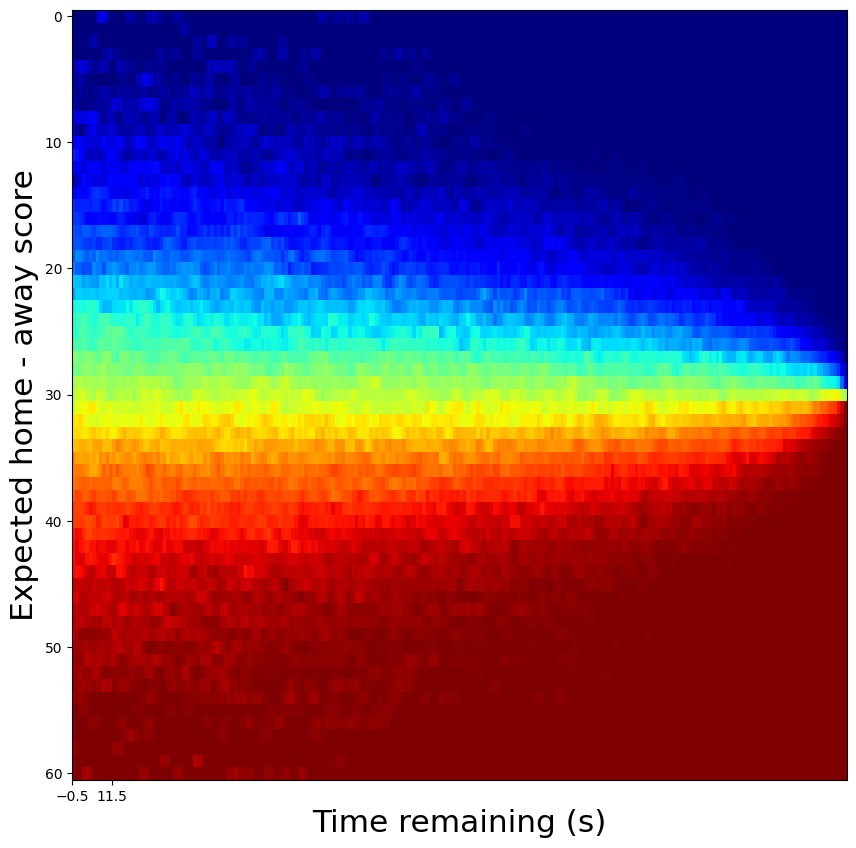

In [236]:
#create wp look-up table based on 3 factors (collapsing team strength + score into 'adjusted wp')
def wpplot(dat,xmx,cbl,sl,vm,vx,pltsin,figp,trh): #function for plotting in wp space
    xdivf,ydivf=8,5
    f,ax=plt.subplots(nrows=1,ncols=1,figsize=(fsz,fsz))
    im=ax.imshow(dat[xmx:,:].T,interpolation='none',aspect='auto',cmap='jet',vmin=vm,vmax=vx)
    ax.set_ylabel('Expected home - away score',fontsize=fs*0.75)
    ax.set_xlabel('Time remaining (s)',fontsize=fs*0.75)
    xt=np.linspace(-0.5,xmx-0.5,int(np.divide(xmx,xdivf))+1)
    xt[-1]=xt[-1]+1
    ax.set_xticks(xt)
    xtl=sl[xmx-1::xdivf].astype(int)
    ax.set_xticklabels(xtl, rotation = 45,fontsize=fs//2)
    ax.set_yticks(np.linspace(-0.5,scoreDiffSteps-0.5,int(np.divide(scoreDiffSteps-1,ydivf))+1))
    ax.set_yticklabels(scoreDiffB[::ydivf].astype(int),fontsize=fs//2)
    ax.invert_yaxis() #invert y axis for preferred viz
    f.subplots_adjust(right=0.8) #adjust so we can add colorbar
    cbar_ax = f.add_axes([0.85, 0.15, 0.05, 0.7])
    cbar=f.colorbar(im, cax=cbar_ax)
    cbar.set_label(cbl,fontsize=fs*0.75)
    cbar.ax.tick_params(labelsize=fs//2)
    if pltsin: #add sin wave to show periodicity of wp advantage
        time=np.arange(0, 120, 0.1);
        amplitude=np.sin(time*(np.pi)/3.5-9)*5
        ax.plot(time[:-1],amplitude[:-1]+xsd,'k',linewidth=2)
        plt.show()
    if figp>0:
        fn='figs/wpplot'+str(figp)+'-'+str(trh)+'.pdf'
        f.savefig(fn, transparent=True)

tSec=12*4*6
secSteps=int(tSec/6)
q4i=int(np.divide(secSteps-2,4))
wpplot(fact4i2[:,:,0],q4i,'Win probability',secB2,0,1,0,1,tr_half)
wpplot(fact4i2[:,:,1],q4i,'Win probability',secB2,0,1,0,2,tr_half)
wpplot(abs(fact4i2[:,:,0]-fact4i2[:,:,1]),q4i,'Win probability difference',secB2,0,0.15,0,3,tr_half)

In [12]:
ldf=len(df1)
#find minimum WP of winning team - used later to compute comeback data
#create surprise data
mwwp,fgsur,mwwp_t,sur,maxsur=np.zeros((ldf)),np.zeros((ldf)),np.zeros((ldf)),np.zeros((ldf)),np.zeros((ldf))
wgsur=np.zeros((ldf))
ids,k=df1.g_id.unique(),0
print('# games:',len(ids))
for i,ii in enumerate(ids): #loop through all games
    qq=np.where(df1['g_id']==ii)[0] # find rows of this game
    if int(df1['sdiff'][qq[-1]])>0: #if home team won
        minwwp=np.min(df1['hwp'][qq]) #find minimum hwp
        #use absolute here because there are some miniscule rounding errors
        mwwpi=np.where(np.absolute(df1['hwp'][qq]-minwwp)<0.0001)[0]
        firstwwp=df1['hwp'][qq[0]]
        fgsur[qq]=1-df1['hwp'][qq[0]]
        wgsur[qq]=1-minwwp
    else: #away team won
        minwwp=1-np.max(df1['hwp'][qq]) #find maximum hwp
        mwwpi=np.where(np.absolute(df1['hwp'][qq]-(1-minwwp))<0.0001)[0]
        firstwwp=1-df1['hwp'][qq[0]]
        fgsur[qq]=0-df1['hwp'][qq[0]]
        wgsur[qq]=-minwwp
    mwwp_t_i=df1['sl'][qq[mwwpi[0]]]
    mwwp_t[qq]=mwwp_t_i+0 #time in game of moment furthest from comeback        
    mwwp[qq]=minwwp
    
    #find 'diff' matrix on wps, move it all back one (so surprise is aligned w/ beginning of possession) 
    #and nan out 1st entry
    diffmat=np.diff(df1['hwp'][qq])
    sur[qq[0]]=math.nan
    sur[qq[1]:qq[-1]+1]=diffmat
    curr_maxsur=np.max(diffmat)
    maxsur[qq]=curr_maxsur
    if k==0: 
        maxsurs,mwwps,mwwp_ts,fwwps=curr_maxsur+0,minwwp+0,mwwp_t_i+0,firstwwp+0
        allsurs=diffmat.T
        k=1
    else:
        maxsurs=np.vstack([maxsurs,curr_maxsur])
        mwwps=np.vstack([mwwps,minwwp])
        mwwp_ts=np.vstack([mwwp_ts,mwwp_t_i])
        fwwps=np.vstack([fwwps,firstwwp])
        allsurs=np.hstack([allsurs,diffmat.T])
    if i%10000==0: #progress
        print(i)
df1['mwwp']=mwwp
df1['sur']=sur
df1['fgsur']=fgsur
df1['wgsur']=wgsur
df1['maxsur']=maxsur
df1['mwwp_t']=mwwp_t

#save data
df1.to_csv('pydata/df1.csv',index=False) 
np.save('pydata/allsurs.npy',allsurs)
np.save('pydata/secB.npy',secB)
np.save('pydata/mwwps.npy',mwwps)
np.save('pydata/mwwp_ts.npy',mwwp_ts)
np.save('pydata/maxsurs.npy',maxsurs)
np.save('pydata/fwwps.npy',fwwps)

# games: 22539
0
10000
20000


In [13]:
#compare our model to linear and logistic regression (using the same factors)
#qq=np.where(df1['sl_ot'].values<300)[0] #last 5 minutes only, just to check
qq=np.where(df1['sl_ot'].values<3000)[0] #whole game

#try a linear model
x0=df1['sl_ot'][qq].values #predictors
x1=df1['sdiff_adj'][qq].values
x2=df1['hp'][qq].values
y=df1['hw'][qq].values #outcome
y_4f=df1['hwp'][qq].values #our 4-factor model outcome
x=np.vstack([x0,x1])
x=np.vstack([x,x2]).T
print(x.shape)
print(y.shape)
model = LinearRegression().fit(x, y) #fit model
y_pred = model.predict(x)
mean_err_lin=np.mean(np.absolute(y-y_pred))
print('mean err of linear regression:',mean_err_lin)
model = LogisticRegression().fit(x, y)
y_pred = model.predict_proba(x) #don't use '.predict' - it just guesses the winner!
mean_err_lin=np.mean(np.absolute(y-y_pred[:,1]))
print('mean err of logistic regression:',mean_err_lin)
mean_err_4f=np.mean(np.absolute(y-y_4f))
print('mean err of 4-factor model:',mean_err_4f)

(5683581, 3)
(5683581,)
mean err of linear regression: 0.35459055763822256
mean err of logistic regression: 0.31643139655644037
mean err of 4-factor model: 0.3044969859516888


In [22]:
#print some outputs of interest: 
print('# rows in PBP data:',ldf)
print('win prob differences going from -4 to +4 with e.g., 5 s left:\n',fact4i2[-3,26:35,0])
print('win prob differences going from -4 to +4 with e.g., 3 s left:\n',fact4i2[-2,26:35,0])
print('win prob differences going from -4 to +4 with e.g., 1 s left:\n',fact4i2[-1,26:35,0])

# rows in PBP data: 5683581
win prob differences going from -4 to +4 with e.g., 5 s left:
 [0.01603376 0.08893709 0.17523168 0.339381   0.65497553 0.89768977
 0.94323144 0.98408104 0.99840256]
win prob differences going from -4 to +4 with e.g., 3 s left:
 [0.00565771 0.04014599 0.10049261 0.22432432 0.57545487 0.94714286
 0.96659708 0.99221032 1.        ]
win prob differences going from -4 to +4 with e.g., 1 s left:
 [0.         0.01027397 0.06465517 0.12933754 0.55480379 0.98644068
 0.99204244 0.99773243 1.        ]
